# jeanie: the same model, solved differently

`jeanie` solves the isothermal Jeans model for an SIDM halo matched to a CDM
outer halo at radius $r_1$ — the model of
[arXiv:2511.10765](https://arxiv.org/abs/2511.10765) — by a reduced numerical
route rather than the package's 402-dimensional relaxation.

This notebook checks it gives the same answer as `jeans`, and shows what that
buys. The companion notebook, `jeanie_differentiable.ipynb`, covers the things
`jeans` cannot do at all.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

import jeans                      # the package: the reference
from jeans.classes import CDM_profile
import jeanie                     # the fast path
from jeanie.outer import boundary_data
from jeanie.solver import solve_spherical

GN = 4.302e-6                     # km^2/s^2 kpc / Msun

# A Milky-Way-like host: NFW halo plus a Miyamoto-Nagai disc.
r1, M200, c = 12.0, 1e12, 10.0
Md, a_d, b_d = 6e10, 3.0, 0.28

def Phi_b(r, th):
    return -GN * Md / np.sqrt(
        r ** 2 * np.sin(th) ** 2
        + (a_d + np.sqrt(b_d ** 2 + r ** 2 * np.cos(th) ** 2)) ** 2)

## The solve

Both solve the same equations. `jeans.spherical` relaxes the full profile on a
grid; `jeanie` reduces the problem to a two-parameter root-find on fixed RK4
nodes and inverts it by bracketing.

In [2]:
# warm numba first, or the first jeanie call times its own compilation
solve_spherical(r1, 1e6, 1e10, Phi_b=Phi_b)

t0 = time.perf_counter()
pkg = jeans.spherical(r1, M200, c, Phi_b=Phi_b)
t_pkg = time.perf_counter() - t0

halo = CDM_profile(M200, c, q0=1.0, Phi_b=Phi_b)
rho1, M1, _ = boundary_data(halo, r1, L_list=(0,))

t0 = time.perf_counter()
fast = solve_spherical(r1, rho1, M1, Phi_b=Phi_b, trajectory=True)
t_fast = time.perf_counter() - t0

print(f"jeans    r0 = {pkg.inner.r0:.6f} kpc   sigma0 = {pkg.inner.sigma0:.4f} km/s"
      f"   [{t_pkg:6.2f} s]")
print(f"jeanie   r0 = {fast.r0:.6f} kpc   sigma0 = {fast.sigma0:.4f} km/s"
      f"   [{t_fast:6.3f} s]")
print(f"\nagreement: r0 {abs(fast.r0/pkg.inner.r0 - 1):.2e}, "
      f"sigma0 {abs(fast.sigma0/pkg.inner.sigma0 - 1):.2e}")
print(f"speedup  : {t_pkg/t_fast:.0f}x")

jeans    r0 = 1.750342 kpc   sigma0 = 156.5569 km/s   [  2.49 s]
jeanie   r0 = 1.750607 kpc   sigma0 = 156.5550 km/s   [ 0.018 s]

agreement: r0 1.51e-04, sigma0 1.25e-05
speedup  : 142x


## Density profiles

The two should lie on top of each other. The lower panel is the residual, which
is set by the reduced solver's fixed step count rather than by any difference
in the physics.

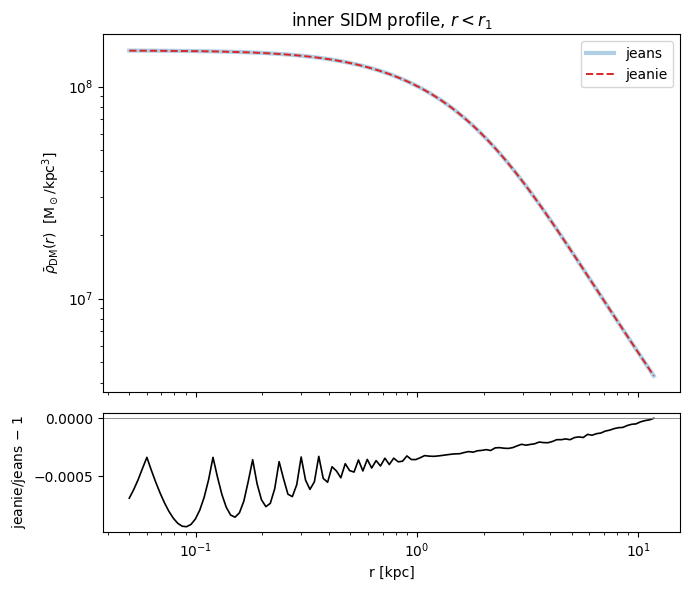

worst relative difference: 9.30e-04


In [3]:
r = np.logspace(-1.3, 1.07, 120)
r = r[r < r1]

rho_pkg = np.array([float(pkg.rho_sph_avg(x)) for x in r])
rho_fast = np.array([float(fast.rho(float(x))) for x in r])

fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                        gridspec_kw={'height_ratios': [3, 1]})
axs[0].loglog(r, rho_pkg, lw=3, alpha=0.35, c='C0', label='jeans')
axs[0].loglog(r, rho_fast, lw=1.4, ls='--', c='C3', label='jeanie')
axs[0].set_ylabel(r'$\bar\rho_{\rm DM}(r)$  [M$_\odot$/kpc$^3$]')
axs[0].legend(); axs[0].set_title('inner SIDM profile, $r < r_1$')

axs[1].semilogx(r, rho_fast / rho_pkg - 1.0, c='k', lw=1.2)
axs[1].axhline(0, c='grey', lw=0.6)
axs[1].set_xlabel('r [kpc]'); axs[1].set_ylabel('jeanie/jeans $-$ 1')
plt.tight_layout(); plt.show()

print(f"worst relative difference: {np.max(np.abs(rho_fast/rho_pkg - 1)):.2e}")

## Where the time goes

The reduction is not a faster language — it is a smaller problem. The package
evaluates its angular integrals with adaptive quadrature and relaxes 402
unknowns; `jeanie` uses fixed Gauss-Legendre nodes and solves for two.

In [4]:
import jeanie.branch as branch
from jeanie.solver import _Problem

reps = 5
methods = {
    'jeanie, bracketed (default)': lambda: solve_spherical(r1, rho1, M1, Phi_b=Phi_b),
    'jeanie, continuation':        lambda: solve_spherical(r1, rho1, M1, Phi_b=Phi_b,
                                                           method='ramp', verify=False),
}
for name, fn in methods.items():
    fn()                                            # warm numba
    t0 = time.perf_counter()
    for _ in range(reps):
        fn()
    print(f"  {name:30s} {(time.perf_counter()-t0)/reps*1e3:7.1f} ms")
print(f"  {'jeans.spherical':30s} {t_pkg*1e3:7.1f} ms   (once; not repeated)")

  jeanie, bracketed (default)       11.7 ms


  jeanie, continuation              30.3 ms
  jeans.spherical                 2492.3 ms   (once; not repeated)
